# ✈️ Orquestador ELT – Flights & Airports

Este notebook ejecuta y documenta el flujo **Extract → Load → Transform (ELT)** del proyecto.

## 🎯 Objetivos
- **Extract:** consultar la API de AviationStack y persistir crudos en **Parquet**.
- **Load:** cargar crudos a **Delta Lake** (control de esquema e histórico).
- **Transform:** aplanar, limpiar y enriquecer datos listos para análisis.

## ✅ Justificación de elecciones
- **Parquet:** formato columnar eficiente para crudos, compresión y tipos estables.
- **Delta Lake:** *ACID*, control de esquema, versionado, y soporte de partición por fecha.
- **Pandas:** flexibilidad y velocidad para prototipado de transformaciones.
- **Notebook:** narrativa reproducible, perfecta para defensa de la consigna.


## 🔧 Configuración inicial

In [1]:
# Asegurar imports y rutas
import os
import pandas as pd
from deltalake import DeltaTable
from pathlib import Path

# Rutas principales del data lake
DATA_LAKE = Path("../data_lake")
FLIGHTS_PROCESSED = DATA_LAKE / "flights" / "processed"
AIRPORTS_PROCESSED = DATA_LAKE / "airports" / "processed"
ENRICHED = DATA_LAKE / "flights" / "processed_enriched_pandas"
AGG = DATA_LAKE / "flights" / "agg_by_status"

DATA_LAKE, FLIGHTS_PROCESSED, AIRPORTS_PROCESSED, ENRICHED, AGG


(WindowsPath('../data_lake'),
 WindowsPath('../data_lake/flights/processed'),
 WindowsPath('../data_lake/airports/processed'),
 WindowsPath('../data_lake/flights/processed_enriched_pandas'),
 WindowsPath('../data_lake/flights/agg_by_status'))

## 1️⃣ Extract

Ejecuta `extract.py`. En caso de error de API (401/429), el script **siempre** guarda Parquet con columnas esperadas, evitando que el pipeline se rompa.


In [2]:
!python ../src/extract.py

[2025-08-24 01:55:47] ▶️ Iniciando extracción de datos...
[2025-08-24 01:55:49] ✅ Extracción de vuelos exitosa. 100 filas guardadas.
[2025-08-24 01:55:50] ✅ Extracción de aeropuertos exitosa. 100 filas guardadas.
[2025-08-24 01:55:50] ✅ Proceso de extracción finalizado.


## 2️⃣ Load

Ejecuta `load.py` y escribe tablas Delta. Se utiliza **hard overwrite** en la primera corrida para evitar conflictos de esquema entre ejecuciones de prueba.


In [3]:
!python ../src/load.py

[2025-08-24 01:55:52] ✅ Crudos cargados: flights=100 filas, airports=100 filas
[2025-08-24 01:55:52] ✅ Guardado 100 filas en c:\Users\MONSO\OneDrive\Escritorio\Proyecto-ELT\data_lake\flights\processed (modo=overwrite, partition_by=['flight_date'])
[2025-08-24 01:55:52] ✅ Guardado 100 filas en c:\Users\MONSO\OneDrive\Escritorio\Proyecto-ELT\data_lake\airports\processed (modo=overwrite, partition_by=None)
[2025-08-24 01:55:52] ✅ Datos cargados en Delta Lake.


## 3️⃣ Transform

Ejecuta `transform.py` que:
- Aplana estructuras JSON (`departure`, `arrival`, `airline`, `flight`, `aircraft`, `live`).
- Normaliza tipos, maneja nulos y crea columnas faltantes críticas.
- Enriquce con nombres de aeropuertos y marca vuelos con retraso (`is_delayed`).

In [4]:
!python ../src/transform.py

[2025-08-24 01:55:53] 🔄 Cargando tablas Delta...
[2025-08-24 01:55:53] ✅ Cargados 100 vuelos y 100 aeropuertos.
[2025-08-24 01:55:53] 🧹 Limpiando y aplanando DataFrame de vuelos...
[2025-08-24 01:55:53] 🤝 Enriqueciendo datos...
[2025-08-24 01:55:53] ✅ Limpieza y enriquecimiento completado.
[2025-08-24 01:55:53] ✅ Guardado 100 filas en c:\Users\MONSO\OneDrive\Escritorio\Proyecto-ELT\data_lake\flights\processed_enriched_pandas (modo=overwrite, partition_by=['flight_date'])
[2025-08-24 01:55:53] ✅ Guardado DataFrame final en c:\Users\MONSO\OneDrive\Escritorio\Proyecto-ELT\data_lake\flights\processed_enriched_pandas
[2025-08-24 01:55:53] 📊 Agregando datos por estado...
[2025-08-24 01:55:53] ✅ Guardado 2 filas en c:\Users\MONSO\OneDrive\Escritorio\Proyecto-ELT\data_lake\flights\agg_by_status (modo=overwrite, partition_by=None)
[2025-08-24 01:55:53] ✅ Guardado DataFrame de agregación en c:\Users\MONSO\OneDrive\Escritorio\Proyecto-ELT\data_lake\flights\agg_by_status


c:\Users\MONSO\OneDrive\Escritorio\Proyecto-ELT\src\transform.py:150: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['flight_date'] = df_final['flight_date'].astype('string').fillna('unknown')
c:\Users\MONSO\OneDrive\Escritorio\Proyecto-ELT\src\transform.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pandas[col] = df_pandas[col].astype('string').fillna('')
c:\Users\MONSO\OneDrive\Escritorio\Proyecto-ELT\src\transform.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

## 4️⃣ Validación rápida de resultados

Leemos las tablas Delta generadas y mostramos conteos básicos para asegurar que el pipeline corrió.


In [5]:
from utils import log

def load_delta_safe(path: Path):
    if path.exists():
        return DeltaTable(str(path)).to_pandas()
    else:
        log(f"⚠️ No existe la tabla: {path}")
        return pd.DataFrame()

df_flights = load_delta_safe(FLIGHTS_PROCESSED)
df_airports = load_delta_safe(AIRPORTS_PROCESSED)
df_enriched = load_delta_safe(ENRICHED)

log(f"Vuelos (raw→Delta): {len(df_flights)} filas")
log(f"Aeropuertos (raw→Delta): {len(df_airports)} filas")
log(f"Vuelos enriquecidos: {len(df_enriched)} filas")

# Mostrar un preview elegante
display(df_enriched.head(10))


[2025-08-24 01:55:54] Vuelos (raw→Delta): 100 filas
[2025-08-24 01:55:54] Aeropuertos (raw→Delta): 100 filas
[2025-08-24 01:55:54] Vuelos enriquecidos: 100 filas


,flight_date,status,is_delayed,departure_iata_code,departure_airport_name,arrival_iata_code,arrival_airport_name
0,2025-08-24,scheduled,0.0,,,,
1,2025-08-24,scheduled,0.0,,,,
2,2025-08-24,scheduled,0.0,,,,
3,2025-08-24,scheduled,0.0,,,,
4,2025-08-24,scheduled,0.0,,,,
5,2025-08-24,scheduled,0.0,,,,
6,2025-08-24,scheduled,0.0,,,,
7,2025-08-24,scheduled,0.0,,,,
8,2025-08-24,scheduled,0.0,,,,
9,2025-08-24,scheduled,0.0,,,,


## 5️⃣ Métricas y visualizaciones

Algunas métricas útiles para la demo:
- Distribución por `flight_status`.
- % de vuelos con retraso (`is_delayed`).
- Top aeropuertos de salida por volumen.


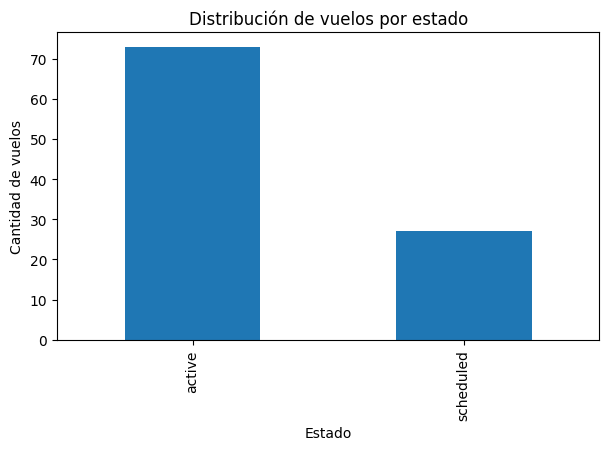

% de vuelos retrasados: 0.00%


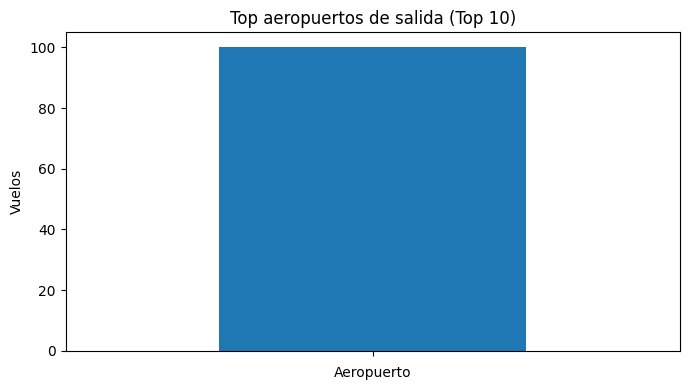

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from deltalake import DeltaTable

# Ruta a la tabla Delta enriquecida
enriched_path = '..\\data_lake\\flights\\processed_enriched_pandas'

# Cargar la tabla Delta
try:
    df_enriched = DeltaTable(enriched_path).to_pandas()
except Exception as e:
    print(f"❌ Error al cargar la tabla Delta: {e}")
    df_enriched = pd.DataFrame()

if not df_enriched.empty:
    # 1. Distribución por estado (usando el nombre de columna correcto: 'status')
    status_counts = df_enriched['status'].value_counts(dropna=False).sort_values(ascending=False)
    ax = status_counts.plot(kind='bar', figsize=(7, 4))
    ax.set_title('Distribución de vuelos por estado')
    ax.set_xlabel('Estado')
    ax.set_ylabel('Cantidad de vuelos')
    plt.show()

    # 2. % de vuelos retrasados (usando el nombre de columna correcto: 'is_delayed')
    if 'is_delayed' in df_enriched.columns:
        delayed_rate = (df_enriched['is_delayed'].astype(bool).mean() * 100)
        print(f"% de vuelos retrasados: {delayed_rate:.2f}%")
    else:
        print("⚠️ Columna 'is_delayed' no encontrada. No se puede calcular el porcentaje.")

    # 3. Top aeropuertos de salida (usando el nombre de columna correcto: 'departure_airport_name')
    if 'departure_airport_name' in df_enriched.columns:
        top_airports = df_enriched['departure_airport_name'].value_counts().head(10)
        ax = top_airports.plot(kind='bar', figsize=(7, 4))
        ax.set_title('Top aeropuertos de salida (Top 10)')
        ax.set_xlabel('Aeropuerto')
        ax.set_ylabel('Vuelos')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Columna 'departure_airport_name' no encontrada. No se pueden mostrar los principales aeropuertos.")
else:
    print("No hay datos enriquecidos para visualizar. Asegúrate de que los scripts 'extract' y 'load' se ejecutaron con éxito.")


---
### ♻️ Reproducibilidad
- Ejecutá las celdas en orden (1→2→3→4→5).
- Si cambiás el esquema en pruebas, corré de nuevo **Load** y **Transform** para regenerar Delta con *hard overwrite*.
- Configurá `AVIATIONSTACK_API_KEY` en tu entorno para obtener datos reales.
